# Red urbana

## Configuración del entorno

Importamos librerías y dependencias.

In [1]:
import geopandas as gpd
import osmnx as ox
from pathlib import Path

Configuración de OSMnx

In [2]:
ox.settings.use_cache = True
ox.settings.log_console = False

## Descargar red urbana de Rosario

In [3]:
place = "Rosario, Santa Fe, Argentina"
grafo = ox.graph_from_place(place, network_type="walk", simplify=True)

In [8]:
print(grafo)
print(f"CRS: {grafo.graph["crs"]}")

MultiDiGraph with 21369 nodes and 68914 edges
CRS: epsg:4326


In [ ]:
grafo = ox.project_graph(grafo, to_crs="EPSG:22185")

In [11]:
print(grafo)
print(f"CRS: {grafo.graph["crs"]}")

MultiDiGraph with 21369 nodes and 68914 edges
CRS: EPSG:22185


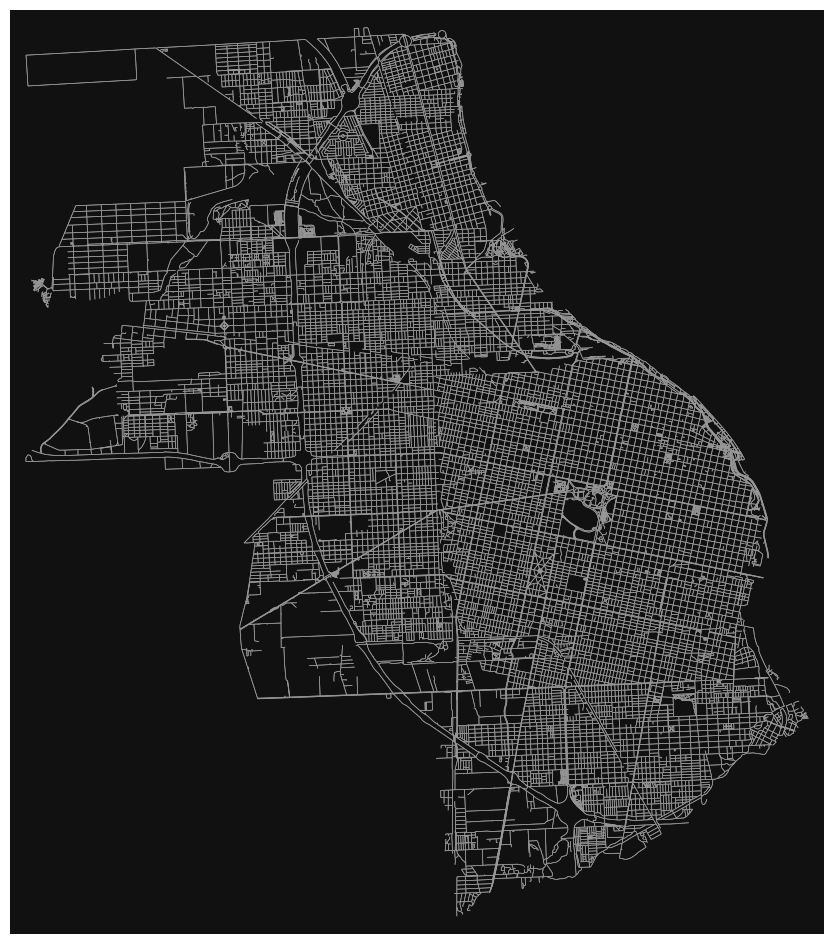

In [10]:
fig, ax = ox.plot_graph(
    grafo,
    node_size=0,
    edge_linewidth=0.5,
    figsize=(12, 12)
)

In [ ]:
nodos, calles = ox.graph_to_gdfs(grafo)

In [14]:
display(nodos.head())

,y,x,street_count,highway,railway,ref,geometry
osmid,,,,,,,
92065725,6.349286e+06,5.437842e+06,4,NaN,NaN,NaN,POINT (5437841.794 6349286.286)
5077530857,6.349276e+06,5.437842e+06,3,traffic_signals,NaN,NaN,POINT (5437842.216 6349275.785)
13379502651,6.349287e+06,5.437868e+06,4,NaN,NaN,NaN,POINT (5437867.602 6349287.314)
13379506624,6.349295e+06,5.437842e+06,3,crossing,NaN,NaN,POINT (5437841.825 6349294.76)
1636740357,6.349286e+06,5.437828e+06,4,crossing,NaN,NaN,POINT (5437827.835 6349285.61)


In [13]:
display(calles.head())

osmid      highway lanes maxspeed  \
u          v           key                                          
92065725   5077530857  0    278443870      primary     3       70   
           13379502651 0    475625066  residential     2       40   
           13379506624 0    496954584      primary     3       70   
           1636740357  0    587287801  residential     2       40   
5077530857 92065725    0    278443870      primary     3       70   

                                                  name  oneway reversed  \
u          v           key                                                
92065725   5077530857  0         Bulevar Nicasio Oroño   False     True   
           13379502651 0    Gregorio Aráoz de Lamadrid   False    False   
           13379506624 0         Bulevar Nicasio Oroño   False    False   
           1636740357  0    Gregorio Aráoz de Lamadrid   False     True   
5077530857 92065725    0         Bulevar Nicasio Oroño   False    False   

                               length  \
u          v           key              
92065725   5077530857  0    10.536136   
           13379502651 0    25.772616   
           13379506624 0     8.495719   
           1636740357  0    13.945288   
5077530857 92065725    0    10.536136   

                                                                     geometry  \
u          v           key                                                      
92065725   5077530857  0    LINESTRING (5437841.794 6349286.286, 5437842.2...   
           13379502651 0    LINESTRING (5437841.794 6349286.286, 5437867.6...   
           13379506624 0    LINESTRING (5437841.794 6349286.286, 5437841.8...   
           1636740357  0    LINESTRING (5437841.794 6349286.286, 5437827.8...   
5077530857 92065725    0    LINESTRING (5437842.216 6349275.785, 5437841.7...   

                           access service width tunnel junction bridge  ref  
u          v           key                                                   
92065725   5077530857  0      NaN     NaN   NaN    NaN      NaN    NaN  NaN  
           13379502651 0      NaN     NaN   NaN    NaN      NaN    NaN  NaN  
           13379506624 0      NaN     NaN   NaN    NaN      NaN    NaN  NaN  
           1636740357  0      NaN     NaN   NaN    NaN      NaN    NaN  NaN  
5077530857 92065725    0      NaN     NaN   NaN    NaN      NaN    NaN  NaN